In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import numpy as np
from unet import *
import datasets
import training

# Prevents crashes when showing graphs
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
SIM_STEPS = 201

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
import torch
from datasets import FixedDenseDatasetLimited
from training import train_masked

In [3]:
# Pre-Determined train/test/val split
train_sims = np.load("../train_sims.npy")
train_sims = train_sims[train_sims < 501]
val_sims = np.load("../val_sims.npy")
val_sims = val_sims[val_sims < 501]
test_sims = np.load("../test_sims.npy")
test_sims = test_sims[test_sims < 501]

In [4]:
def make_circle_mask(H=200, W=200, points_per_side=3, radius=5):
    mask = torch.zeros((H, W), dtype=torch.bool)

    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")

    div = points_per_side + 1
    point_x = torch.arange(W // div, W, W // div)
    point_y = torch.arange(H // div, H, H // div)

    for y0 in point_y:
        for x0 in point_x:
            disk = (yy - int(y0))**2 + (xx - int(x0))**2 <= radius**2
            mask |= disk

    return mask

def make_boundary_mask(H=200, W=200, thickness=3):
    mask = torch.zeros((H, W), dtype=torch.bool)

    # top + bottom
    mask[:thickness, :] = True
    mask[-thickness:, :] = True

    # optional: left/right too
    # mask[:, :thickness] = True
    # mask[:, -thickness:] = True

    return mask

def make_hybrid_mask():
    mask1 = make_circle_mask()
    mask2 = make_boundary_mask()

    return mask1 | mask2

def make_single_line_mask(H=200, W=200):
    mask = torch.zeros((H, W), dtype=torch.bool)
    mask[H // 2, :] = True
    return mask

def make_random_mask(H=200, W=200, num_points=50):
    mask = torch.zeros((H, W), dtype=torch.bool)

    ys = torch.randint(0, H, (num_points,))
    xs = torch.randint(0, W, (num_points,))

    mask[ys, xs] = True
    return mask

In [5]:
# where to save trained models
SAVE_DIR = "./mask_models"
os.makedirs(SAVE_DIR, exist_ok=True)

mask_tests = {
    "circles": make_circle_mask(),
    "boundary": make_boundary_mask(),
    "hybrid": make_hybrid_mask()
}

results = {}

for name, mask in mask_tests.items():
    name +="_ADAM"
    print(f"Running {name}")

    dataset_arguments = {
        "points_per_side": 3,
        "radius": 5,
        "steps": (0, 200),
        "types": [0],
        "wiggle": 0,
        "H": 200,
        "W": 200,
        "channels": "all",
        "future_delta": 0,
        "given_mask": mask
    }

    model, train_losses, val_losses = training.train_from_scratch(
        dataset_type=datasets.FixedDenseDatasetLimited,
        dataset_arguments=dataset_arguments,
        train_sims=train_sims,
        val_sims=val_sims,
        optimizer=lambda params: torch.optim.Adam(params, lr=1e-3),
        min_epochs=5,
        max_epochs=20,
        device=device,
        loss_weights_init=(1.0, 0.0),           # baseline: MSE only
        physics_fn=training.darcy_loss        # baseline: no physics loss
    )

    # save model weights for later testing
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"adam_{name}.pt"))

    results[name] = {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

Running circles_ADAM


100%|██████████| 20/20 [2:46:47<00:00, 500.37s/it]  


Running boundary_ADAM


100%|██████████| 20/20 [2:39:08<00:00, 477.44s/it]  


Running hybrid_ADAM


100%|██████████| 20/20 [2:39:35<00:00, 478.76s/it]  


In [ ]:
# where to save trained models
SAVE_DIR = "./mask_models"
os.makedirs(SAVE_DIR, exist_ok=True)

for name, mask in mask_tests.items():
    name +="_SGDM"
    print(f"Running {name}")

    dataset_arguments = {
        "points_per_side": 3,
        "radius": 5,
        "steps": (0, 200),
        "types": [0],
        "wiggle": 0,
        "H": 200,
        "W": 200,
        "channels": "all",
        "future_delta": 0,
        "given_mask": mask
    }

    model, train_losses, val_losses = training.train_from_scratch(
        dataset_type=datasets.FixedDenseDatasetLimited,
        dataset_arguments=dataset_arguments,
        train_sims=train_sims,
        val_sims=val_sims,
        optimizer=lambda params: torch.optim.SGD(params,lr=1e-2),
        min_epochs=5,
        max_epochs=20,
        device=device,
        loss_weights_init=(1.0, 0.0),           # baseline: MSE only
        physics_fn=training.darcy_loss        # baseline: no physics loss
    )

    # save model weights for later testing
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"SGDM_{name}.pt"))

    results[name] = {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

Running circles_SGDM


100%|██████████| 20/20 [2:35:57<00:00, 467.86s/it]  


Running boundary_SGDM


100%|██████████| 20/20 [2:35:51<00:00, 467.57s/it]  


Running hybrid_SGDM


100%|██████████| 20/20 [2:35:19<00:00, 465.96s/it]  


: 

shape: (200, 200, 3)
dtype: uint8
min/max per channel:
B 0 120
G 0 248
R 0 77


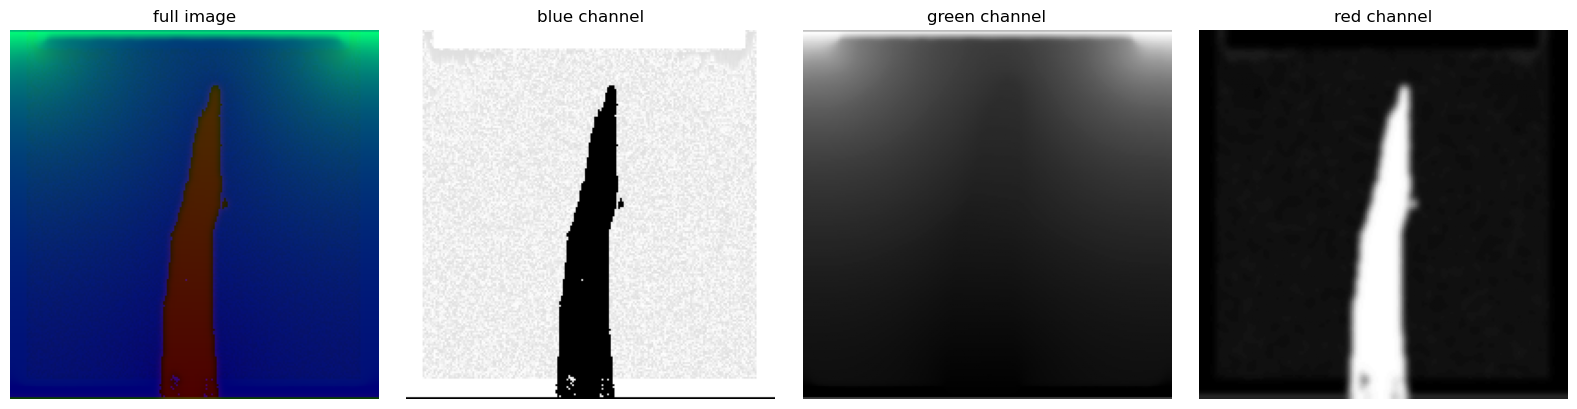

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
path = "../Data200x200_withinfo_Deterministic/Sim-3-Step-121.png"

img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
print("shape:", img.shape)
print("dtype:", img.dtype)

# if color, OpenCV loads BGR by default
if len(img.shape) == 3:
    print("min/max per channel:")
    for i, name in enumerate(["B", "G", "R"]):
        print(name, img[:, :, i].min(), img[:, :, i].max())

    fig, axs = plt.subplots(1, 4, figsize=(16,4))
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axs[0].set_title("full image")

    axs[1].imshow(img[:, :, 0], cmap="gray")
    axs[1].set_title("blue channel")

    axs[2].imshow(img[:, :, 1], cmap="gray")
    axs[2].set_title("green channel")

    axs[3].imshow(img[:, :, 2], cmap="gray")
    axs[3].set_title("red channel")

    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    plt.imshow(img, cmap="gray")
    plt.title("single-channel image")
    plt.axis("off")
    plt.show()